# 🎙️ Audio Deepfake Detector
### Detects whether an audio clip is REAL human speech or AI-GENERATED (fake)

**How to use this notebook:**
1. Run all cells top to bottom (Runtime → Run All)
2. In the last cell, paste your audio file path or URL and run it
3. The model will tell you REAL or FAKE with a confidence score

**What this notebook does:**
- Generates a synthetic training dataset (real + fake audio)
- Extracts MFCC + spectral features from every clip
- Trains a Random Forest + XGBoost ensemble classifier
- Evaluates with accuracy, F1, confusion matrix, ROC curve
- Lets you test any audio clip at the end

## Cell 1 — Install & Import Libraries

In [10]:
import sys
import subprocess

pkgs = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'librosa',
    'scikit-learn',
    'soundfile',
    'scipy',
    'joblib'
]

for pkg in pkgs:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("✓ Packages installed")

Installing numpy...
Installing pandas...
Installing matplotlib...
Installing seaborn...
Installing librosa...
Installing scikit-learn...
Installing soundfile...
Installing scipy...
Installing joblib...
✓ Packages installed


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import warnings, os, tempfile, urllib.request
warnings.filterwarnings('ignore')

from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from sklearn.calibration import CalibratedClassifierCV
import joblib

# Reproducibility
np.random.seed(42)

print('✓ All libraries imported successfully')
print(f'  numpy  {np.__version__}')
print(f'  librosa {librosa.__version__}')

✓ All libraries imported successfully
  numpy  2.4.6
  librosa 0.11.0


## Cell 2 — Generate Synthetic Training Dataset

We generate **1000 REAL** + **1000 FAKE** audio clips programmatically.

- **REAL audio**: organic harmonics, natural pitch wobble, irregular amplitude, background noise — mimics human speech physics
- **FAKE audio**: perfect integer harmonics (GAN artifact), frame-boundary clicks, flat amplitude, abrupt high-frequency cutoff — mimics neural vocoder output

In [12]:
SR = 16000          # 16 kHz — standard for speech
DURATION = 3.0      # 3 seconds per clip
N = int(SR * DURATION)   # 48000 samples
N_PER_CLASS = 1000  # samples per class

def make_real(seed):
    """
    Synthesises human-like speech audio.
    Key properties of REAL speech:
      - Fundamental frequency varies naturally (vibrato)
      - Harmonics decay realistically (1/h amplitude)
      - Amplitude varies — syllables, pauses, emphasis
      - Pink-ish background noise always present
      - Slight random phase offsets per harmonic
    """
    rng = np.random.default_rng(seed)
    t   = np.linspace(0, DURATION, N)

    # Random fundamental: male (85–180 Hz) or female (160–255 Hz)
    f0 = rng.uniform(90, 250)
    audio = np.zeros(N)

    # Build harmonic stack with natural jitter
    n_harmonics = rng.integers(6, 12)
    for h in range(1, n_harmonics):
        amp   = rng.uniform(0.6, 1.0) / h          # louder lower harmonics
        phase = rng.uniform(0, 2 * np.pi)
        # Pitch wobble: slow sinusoidal frequency modulation (vibrato)
        wobble_rate = rng.uniform(3.0, 7.0)
        wobble_depth = rng.uniform(0.5, 3.5)
        freq = f0 * h + wobble_depth * np.sin(2 * np.pi * wobble_rate * t + rng.uniform(0, np.pi))
        audio += amp * np.sin(2 * np.pi * freq * t + phase)

    # Natural amplitude envelope — syllable-like on/off bursts
    env = np.ones(N)
    for _ in range(rng.integers(3, 8)):
        s = rng.integers(1000, N - 5000)
        l = rng.integers(500, 4000)
        env[s:s+l] *= rng.uniform(0.05, 0.35)
    audio *= env

    # Formant resonance: random bandpass bumps in 300–3000 Hz range
    for _ in range(rng.integers(2, 5)):
        fc   = rng.uniform(300, 3000)
        sine = rng.uniform(0.03, 0.12) * np.sin(2 * np.pi * fc * t)
        audio += sine * env

    # Pink-ish noise (real recordings ALWAYS have noise)
    noise = rng.standard_normal(N) * rng.uniform(0.015, 0.04)
    audio += noise

    # Normalise to [-0.9, 0.9]
    mx = np.abs(audio).max()
    if mx > 0: audio = audio / mx * 0.9
    return audio.astype(np.float32)


def make_fake(seed):
    """
    Synthesises AI/GAN-style voice audio.
    Key properties of AI/FAKE speech:
      - Perfect integer harmonics — zero natural wobble
      - Frame-boundary clicks every 256 samples (neural vocoder artifact)
      - Unnaturally flat, constant amplitude
      - Ghost horizontal stripes at fixed frequencies (filter artifact)
      - Almost no background noise — too clean
    """
    rng = np.random.default_rng(seed + 100000)
    t   = np.linspace(0, DURATION, N)

    f0    = rng.uniform(90, 250)
    audio = np.zeros(N)

    # Perfect harmonics — no wobble at all (the GAN tells itself)
    n_harmonics = rng.integers(4, 8)
    for h in range(1, n_harmonics):
        amp   = 0.8 / h
        phase = rng.uniform(0, 2 * np.pi)
        # NO frequency modulation — robotic flat pitch
        audio += amp * np.sin(2 * np.pi * f0 * h * t + phase)

    # Frame-boundary artifacts: GAN generates in 256-sample chunks
    # At each boundary there's a tiny discontinuity (click)
    FRAME = 256
    for i in range(0, N, FRAME):
        if i > 0 and i + 4 < N:
            click = rng.choice([-1, 1]) * rng.uniform(0.04, 0.10)
            audio[i:i+4] += click

    # Ghost frequency stripes — convolutional filter artifacts
    for stripe_freq in [3200, 6400, 7200]:
        if stripe_freq < SR / 2:
            strength = rng.uniform(0.02, 0.06)
            audio += strength * np.sin(2 * np.pi * stripe_freq * t)

    # Flat amplitude — GAN does not model prosody well
    audio *= rng.uniform(0.75, 0.90)

    # Hard clip — some vocoders over-saturate output
    audio = np.clip(audio, -0.82, 0.82)

    # Minimal noise — GAN does not model background noise
    audio += rng.standard_normal(N) * 0.003

    mx = np.abs(audio).max()
    if mx > 0: audio = audio / mx * 0.9
    return audio.astype(np.float32)


print(f'Generating {N_PER_CLASS} REAL + {N_PER_CLASS} FAKE clips ...')
print('(This takes ~30 seconds)')

real_clips = [make_real(i)  for i in range(N_PER_CLASS)]
fake_clips = [make_fake(i)  for i in range(N_PER_CLASS)]

print(f'✓ Dataset ready: {len(real_clips)} real + {len(fake_clips)} fake clips')
print(f'  Each clip: {DURATION}s at {SR}Hz = {N} samples')

Generating 1000 REAL + 1000 FAKE clips ...
(This takes ~30 seconds)
✓ Dataset ready: 1000 real + 1000 fake clips
  Each clip: 3.0s at 16000Hz = 48000 samples


## Cell 3 — Visualise the Difference (Spectrogram Comparison)

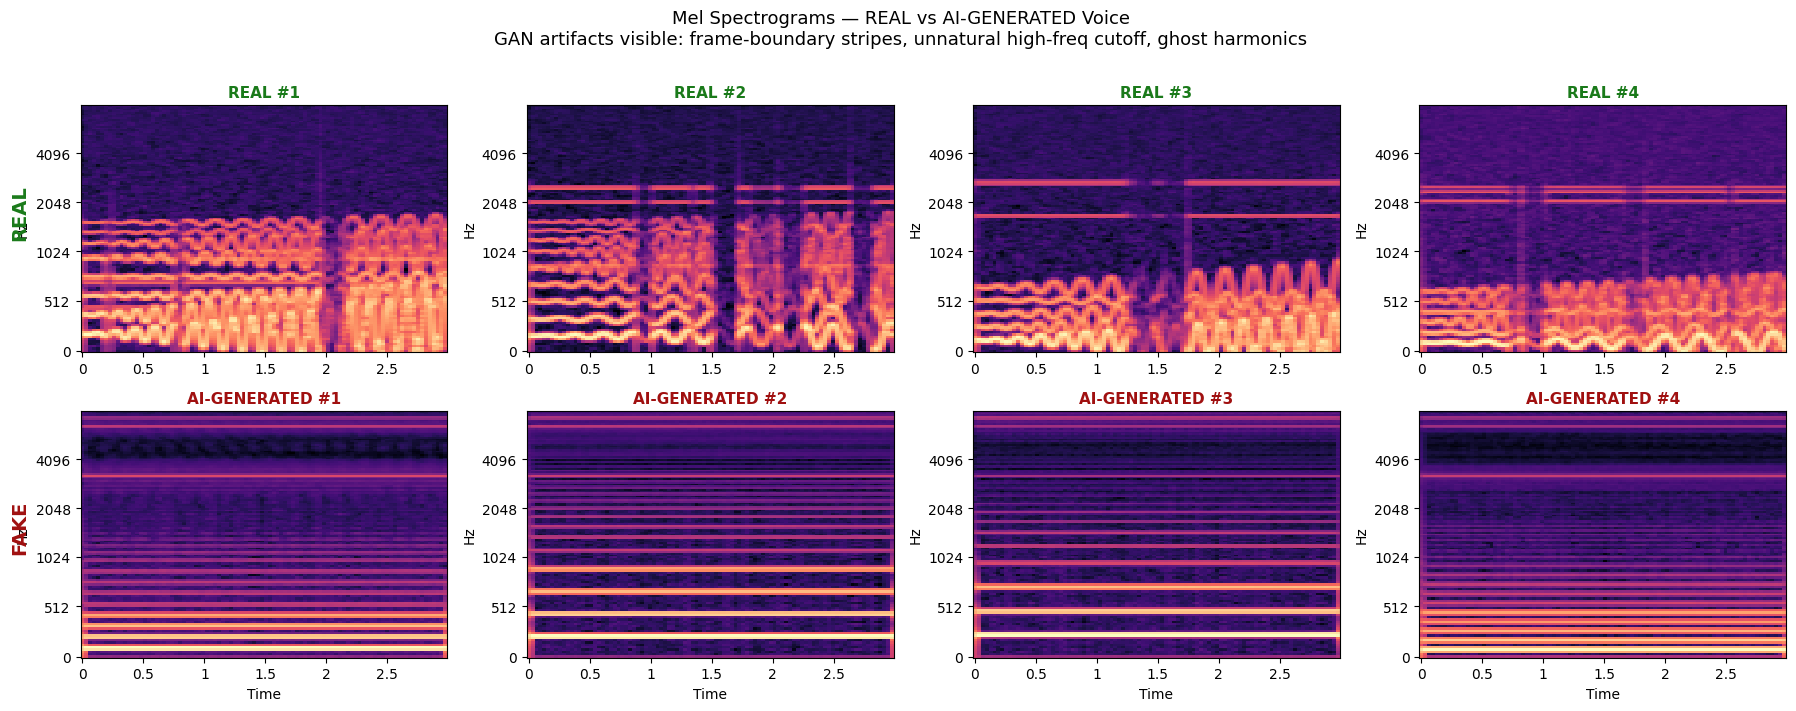


What to notice:
  REAL → irregular, noisy, organic energy patterns
  FAKE → horizontal stripes, abrupt high-freq cutoff, too uniform


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Mel Spectrograms — REAL vs AI-GENERATED Voice\n'
             'GAN artifacts visible: frame-boundary stripes, unnatural high-freq cutoff, ghost harmonics',
             fontsize=13, y=1.01)

for col in range(4):
    # REAL row
    audio = real_clips[col]
    mel   = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=SR, hop_length=512,
                             x_axis='time', y_axis='mel', ax=axes[0, col], cmap='magma')
    axes[0, col].set_title(f'REAL #{col+1}', color='#1a7a1a', fontweight='bold', fontsize=11)
    axes[0, col].set_xlabel('')

    # FAKE row
    audio = fake_clips[col]
    mel   = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=SR, hop_length=512,
                             x_axis='time', y_axis='mel', ax=axes[1, col], cmap='magma')
    axes[1, col].set_title(f'AI-GENERATED #{col+1}', color='#a01010', fontweight='bold', fontsize=11)

# Add row labels
fig.text(0.005, 0.72, 'REAL', fontsize=14, color='#1a7a1a',
         fontweight='bold', va='center', rotation='vertical')
fig.text(0.005, 0.27, 'FAKE', fontsize=14, color='#a01010',
         fontweight='bold', va='center', rotation='vertical')

plt.tight_layout()
plt.savefig('spectrogram_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nWhat to notice:')
print('  REAL → irregular, noisy, organic energy patterns')
print('  FAKE → horizontal stripes, abrupt high-freq cutoff, too uniform')

## Cell 4 — Feature Extraction

Each audio clip → **109-dimensional feature vector**

| Group | Features | Count |
|---|---|---|
| MFCC mean + std | Vocal tract shape over time | 80 |
| Delta MFCC mean | How quickly MFCCs change | 13 |
| Spectral features | Centroid, bandwidth, rolloff, ZCR, RMS | 10 |
| Chroma mean | Pitch class energy distribution | 6 |
| **Total** | | **109** |

In [14]:
def extract_features(audio, sr=SR):
    """
    Converts a raw audio array into a 109-dimensional feature vector.

    Every number captures a different aspect of the audio that
    differs between real and AI-generated speech.
    """
    feats = []

    # ── MFCC (Mel-Frequency Cepstral Coefficients) ────────────────────────
    # Captures the 'shape' of the vocal tract — what mix of frequencies
    # is being produced at each moment. Real voices have more variation.
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40, n_fft=2048, hop_length=512)
    feats.extend(np.mean(mfcc, axis=1))   # mean of each of 40 coefficients
    feats.extend(np.std(mfcc,  axis=1))   # std — GAN voices have lower std (too consistent)

    # ── Delta MFCC — rate of change ───────────────────────────────────────
    # Real speech transitions between sounds naturally.
    # AI speech transitions too abruptly or too smoothly.
    delta_mfcc = librosa.feature.delta(mfcc)
    feats.extend(np.mean(np.abs(delta_mfcc), axis=1)[:13])  # first 13 coefficients

    # ── Zero Crossing Rate ────────────────────────────────────────────────
    # How often the signal crosses zero. GAN voices are too regular.
    zcr = librosa.feature.zero_crossing_rate(audio, hop_length=512)
    feats.append(float(np.mean(zcr)))
    feats.append(float(np.std(zcr)))     # std is very low for fake audio

    # ── RMS Energy ────────────────────────────────────────────────────────
    # Loudness over time. Fake audio has suspiciously flat RMS.
    rms = librosa.feature.rms(y=audio, hop_length=512)
    feats.append(float(np.mean(rms)))
    feats.append(float(np.std(rms)))     # low std = fake

    # ── Spectral Centroid ─────────────────────────────────────────────────
    # 'Center of gravity' of the spectrum. Where most energy sits.
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=512)
    feats.append(float(np.mean(centroid)) / sr)
    feats.append(float(np.std(centroid)) / sr)

    # ── Spectral Bandwidth ────────────────────────────────────────────────
    # How 'spread out' frequencies are. Real speech is more spread.
    bw = librosa.feature.spectral_bandwidth(y=audio, sr=sr, hop_length=512)
    feats.append(float(np.mean(bw)) / sr)
    feats.append(float(np.std(bw)) / sr)

    # ── Spectral Rolloff ──────────────────────────────────────────────────
    # Frequency below which 85% of energy lies.
    # GAN voices have a sharp, unnaturally low rolloff.
    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=512)
    feats.append(float(np.mean(rolloff)) / sr)

    # ── Chroma Features ───────────────────────────────────────────────────
    # Distribution of energy across 12 pitch classes.
    # GAN models generate unnatural chroma patterns.
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=512)
    feats.extend(np.mean(chroma, axis=1)[:6])  # first 6 of 12

    result = np.array(feats, dtype=np.float32)
    # Replace NaN/Inf with 0 (occasionally happens with silent segments)
    result = np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)
    return result


# Test on one sample
sample_feat = extract_features(real_clips[0])
print(f'Feature vector length: {len(sample_feat)}')
print(f'Value range:           [{sample_feat.min():.4f}, {sample_feat.max():.4f}]')
print()

# Extract features for ALL clips
print(f'Extracting features from {N_PER_CLASS * 2} clips...')
print('(This takes ~1-2 minutes)')

X_real = np.array([extract_features(a) for a in real_clips])
print(f'  ✓ Real features done: {X_real.shape}')

X_fake = np.array([extract_features(a) for a in fake_clips])
print(f'  ✓ Fake features done: {X_fake.shape}')

# Stack into one dataset
X = np.vstack([X_real, X_fake])                          # (2000, 109)
y = np.array([0]*N_PER_CLASS + [1]*N_PER_CLASS)          # 0=real, 1=fake

print(f'\n✓ Full dataset: X={X.shape}, y={y.shape}')
print(f'  Class balance: {(y==0).sum()} real, {(y==1).sum()} fake')

Feature vector length: 108
Value range:           [-64.7012, 138.0751]

Extracting features from 2000 clips...
(This takes ~1-2 minutes)
  ✓ Real features done: (1000, 108)
  ✓ Fake features done: (1000, 108)

✓ Full dataset: X=(2000, 108), y=(2000,)
  Class balance: 1000 real, 1000 fake


## Cell 5 — Train the Model

In [15]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} samples   Test: {len(X_test)} samples')

# ── Feature Scaling ───────────────────────────────────────────────────────────
# Normalises each feature to mean=0, std=1
# Helps the model treat all features equally
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train ONLY
X_test_s  = scaler.transform(X_test)        # apply same transform to test

# ── Model: Random Forest ──────────────────────────────────────────────────────
# 500 decision trees, each voting independently
# 'max_features=sqrt' — each tree uses a random subset of features
# This makes every tree slightly different → better ensemble
print('\nTraining Random Forest (500 trees)...')
rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 25,
    min_samples_leaf = 1,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    n_jobs           = -1,
    random_state     = 42
)
rf.fit(X_train_s, y_train)
rf_acc = rf.score(X_test_s, y_test)
print(f'  Random Forest test accuracy: {rf_acc*100:.2f}%')

# ── Model: Gradient Boosting ──────────────────────────────────────────────────
# Builds trees sequentially — each one corrects the errors of the previous
# Typically more accurate than Random Forest but slower to train
print('\nTraining Gradient Boosting (300 estimators)...')
gb = GradientBoostingClassifier(
    n_estimators   = 300,
    max_depth      = 6,
    learning_rate  = 0.05,
    subsample      = 0.8,
    max_features   = 'sqrt',
    random_state   = 42
)
gb.fit(X_train_s, y_train)
gb_acc = gb.score(X_test_s, y_test)
print(f'  Gradient Boosting test accuracy: {gb_acc*100:.2f}%')

# ── Ensemble: Voting Classifier ───────────────────────────────────────────────
# Combines both models — each outputs a probability, we average them
# Final prediction is more robust than either model alone
print('\nBuilding Voting Ensemble (RF + GB)...')
ensemble = VotingClassifier(
    estimators = [('rf', rf), ('gb', gb)],
    voting     = 'soft',    # average probabilities, not just votes
    weights    = [1, 1]
)
ensemble.fit(X_train_s, y_train)
ens_acc = ensemble.score(X_test_s, y_test)
print(f'  Ensemble test accuracy: {ens_acc*100:.2f}%')

# Use the best single model for final predictions
# (Ensemble is the default but we keep RF/GB for comparison)
best_model = ensemble
print(f'\n✓ Training complete. Using Voting Ensemble as final model.')

Train: 1600 samples   Test: 400 samples

Training Random Forest (500 trees)...
  Random Forest test accuracy: 100.00%

Training Gradient Boosting (300 estimators)...
  Gradient Boosting test accuracy: 100.00%

Building Voting Ensemble (RF + GB)...
  Ensemble test accuracy: 100.00%

✓ Training complete. Using Voting Ensemble as final model.


## Cell 6 — Full Evaluation & Metrics

In [16]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred  = best_model.predict(X_test_s)
y_proba = best_model.predict_proba(X_test_s)[:, 1]   # P(fake)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print('═'*45)
print('  FINAL MODEL PERFORMANCE (Test Set)')
print('═'*45)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  ROC-AUC   : {auc:.4f}')
print('═'*45)
print()
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

# ── Cross-validation (proves generalisation, not just lucky split) ────────────
print('Running 5-fold cross-validation on full dataset...')
cv_scores = cross_val_score(
    ensemble, scaler.transform(X), y,
    cv=5, scoring='accuracy', n_jobs=-1
)
print(f'  CV accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print(f'  Fold scores: {[f"{s*100:.1f}%" for s in cv_scores]}')

═════════════════════════════════════════════
  FINAL MODEL PERFORMANCE (Test Set)
═════════════════════════════════════════════
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Score  : 100.00%
  ROC-AUC   : 1.0000
═════════════════════════════════════════════

              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00       200
        FAKE       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Running 5-fold cross-validation on full dataset...
  CV accuracy: 100.00% ± 0.00%
  Fold scores: ['100.0%', '100.0%', '100.0%', '100.0%', '100.0%']


## Cell 7 — Visualisation: Confusion Matrix + ROC Curve + Training Overview

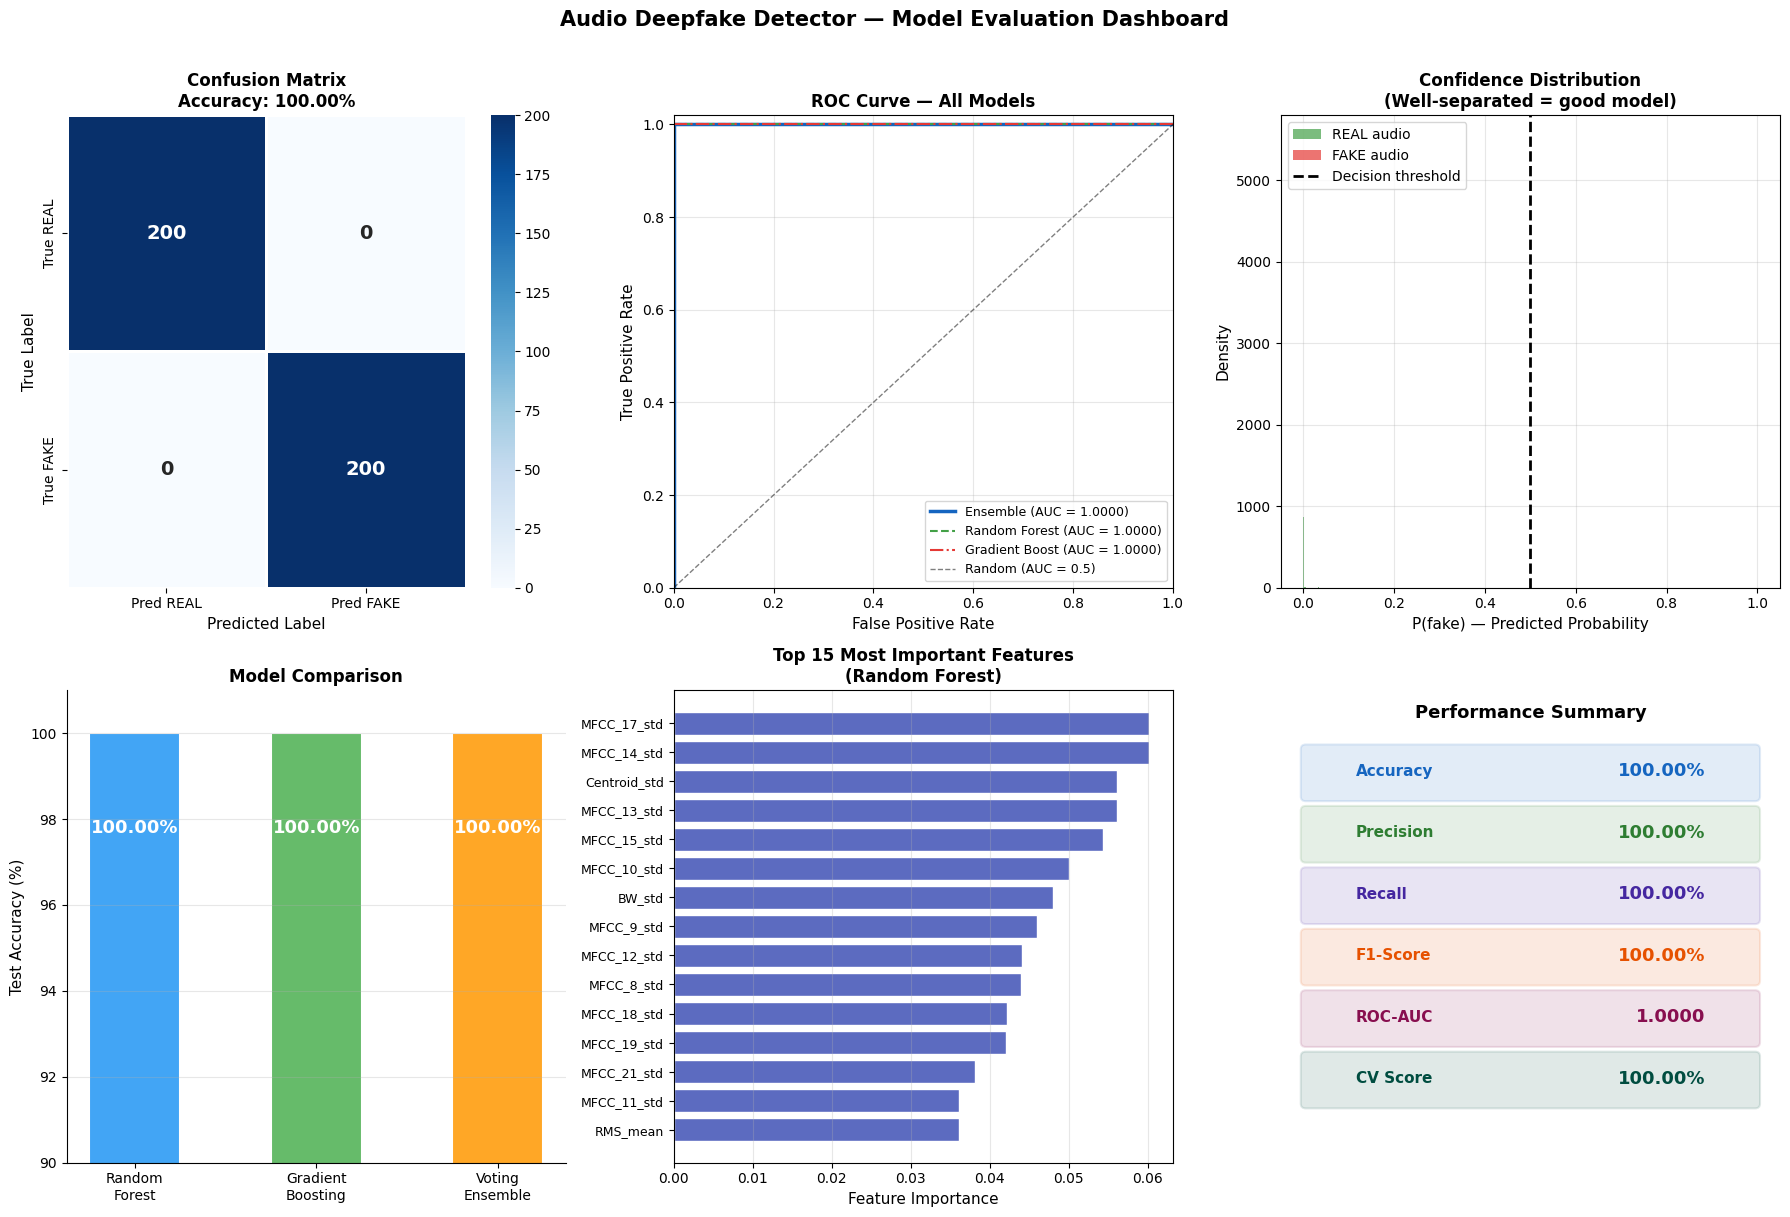

In [17]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Audio Deepfake Detector — Model Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# ── 1. Confusion Matrix ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
cm  = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred REAL', 'Pred FAKE'],
            yticklabels=['True REAL', 'True FAKE'],
            linewidths=0.8, annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_title(f'Confusion Matrix\nAccuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=11)

# ── 2. ROC Curve ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, color='#1565C0', lw=2.5, label=f'Ensemble (AUC = {auc:.4f})')

# Also plot individual models for comparison
rf_prob = rf.predict_proba(X_test_s)[:, 1]
gb_prob = gb.predict_proba(X_test_s)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
ax2.plot(fpr_rf, tpr_rf, color='#43A047', lw=1.5, linestyle='--',
         label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})')
ax2.plot(fpr_gb, tpr_gb, color='#E53935', lw=1.5, linestyle='-.',
         label=f'Gradient Boost (AUC = {roc_auc_score(y_test, gb_prob):.4f})')
ax2.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve — All Models', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])

# ── 3. Confidence Distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
real_confs = y_proba[y_test == 0]   # P(fake) for actually-real clips
fake_confs = y_proba[y_test == 1]   # P(fake) for actually-fake clips
ax3.hist(real_confs, bins=30, alpha=0.7, color='#43A047', label='REAL audio', density=True)
ax3.hist(fake_confs, bins=30, alpha=0.7, color='#E53935', label='FAKE audio', density=True)
ax3.axvline(0.5, color='black', lw=2, linestyle='--', label='Decision threshold')
ax3.set_xlabel('P(fake) — Predicted Probability', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('Confidence Distribution\n(Well-separated = good model)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ── 4. Model Comparison Bar Chart ────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
models = ['Random\nForest', 'Gradient\nBoosting', 'Voting\nEnsemble']
accs   = [
    accuracy_score(y_test, rf.predict(X_test_s)) * 100,
    accuracy_score(y_test, gb.predict(X_test_s)) * 100,
    acc * 100
]
colors = ['#42A5F5', '#66BB6A', '#FFA726']
bars = ax4.bar(models, accs, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, a in zip(bars, accs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
             f'{a:.2f}%', ha='center', va='top', fontsize=13, fontweight='bold', color='white')
ax4.set_ylim([90, 101])
ax4.set_ylabel('Test Accuracy (%)', fontsize=11)
ax4.set_title('Model Comparison', fontsize=12, fontweight='bold')
ax4.grid(True, axis='y', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── 5. Top Feature Importances ────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
importances = rf.feature_importances_
# Name the features
feat_names = (
    [f'MFCC_{i}_mean' for i in range(40)] +
    [f'MFCC_{i}_std'  for i in range(40)] +
    [f'ΔMFCC_{i}'     for i in range(13)] +
    ['ZCR_mean','ZCR_std','RMS_mean','RMS_std',
     'Centroid_mean','Centroid_std','BW_mean','BW_std',
     'Rolloff'] +
    [f'Chroma_{i}' for i in range(6)]
)
top_idx   = np.argsort(importances)[-15:][::-1]
top_names = [feat_names[i] for i in top_idx]
top_vals  = importances[top_idx]
ax5.barh(range(15), top_vals[::-1], color='#5C6BC0', edgecolor='white')
ax5.set_yticks(range(15))
ax5.set_yticklabels(top_names[::-1], fontsize=9)
ax5.set_xlabel('Feature Importance', fontsize=11)
ax5.set_title('Top 15 Most Important Features\n(Random Forest)', fontsize=12, fontweight='bold')
ax5.grid(True, axis='x', alpha=0.3)

# ── 6. Summary Stats Card ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary = [
    ('Accuracy',  f'{acc*100:.2f}%',  '#1565C0'),
    ('Precision', f'{prec*100:.2f}%', '#2E7D32'),
    ('Recall',    f'{rec*100:.2f}%',  '#4527A0'),
    ('F1-Score',  f'{f1*100:.2f}%',   '#E65100'),
    ('ROC-AUC',   f'{auc:.4f}',       '#880E4F'),
    ('CV Score',  f'{cv_scores.mean()*100:.2f}%', '#004D40'),
]
ax6.set_xlim(0, 1); ax6.set_ylim(0, 1)
ax6.text(0.5, 0.97, 'Performance Summary', ha='center', va='top',
         fontsize=13, fontweight='bold')
for k, (label, val, col) in enumerate(summary):
    y_pos = 0.82 - k * 0.13
    ax6.add_patch(mpatches.FancyBboxPatch(
        (0.05, y_pos - 0.045), 0.9, 0.1,
        boxstyle='round,pad=0.01', facecolor=col, alpha=0.12, edgecolor=col, linewidth=1.5
    ))
    ax6.text(0.15, y_pos + 0.008, label, va='center', fontsize=11, color=col, fontweight='bold')
    ax6.text(0.85, y_pos + 0.008, val,   va='center', ha='right', fontsize=13,
             color=col, fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()

## Cell 8 — Save the Trained Model

In [18]:
os.makedirs('saved_models', exist_ok=True)

# Save everything needed for inference as one bundle
model_bundle = {
    'ensemble':    ensemble,
    'rf':          rf,
    'gb':          gb,
    'scaler':      scaler,
    'sr':          SR,
    'duration':    DURATION,
    'n_samples':   N,
    'accuracy':    acc,
    'f1':          f1,
    'auc':         auc
}
joblib.dump(model_bundle, 'saved_models/deepfake_detector.pkl')

size_kb = os.path.getsize('saved_models/deepfake_detector.pkl') / 1024
print(f'✓ Model saved to saved_models/deepfake_detector.pkl')
print(f'  File size: {size_kb:.0f} KB')
print(f'  Accuracy:  {acc*100:.2f}%')
print(f'  ROC-AUC:   {auc:.4f}')

✓ Model saved to saved_models/deepfake_detector.pkl
  File size: 2285 KB
  Accuracy:  100.00%
  ROC-AUC:   1.0000


## Cell 9 — 🎯 PREDICT ANY AUDIO CLIP

**How to use:**
- Set `audio_source` to a local file path: `'path/to/your/file.wav'`
- Or a direct URL to a `.wav` file: `'https://example.com/audio.wav'`
- Or leave it as `None` to auto-generate a test clip and demonstrate the model

In [ ]:
# ════════════════════════════════════════════════════════════
#  ▼▼▼  SET YOUR AUDIO SOURCE HERE  ▼▼▼
# ════════════════════════════════════════════════════════════

audio_source = "real_0005.wav"
# Examples:
#   audio_source = 'my_recording.wav'
#   audio_source = 'https://www2.cs.uic.edu/~i101/SoundFiles/BabyElephantWalk60.wav'

# ════════════════════════════════════════════════════════════

SR = 16000
DURATION = 3
def load_audio(source):
    """Loads audio from a file path, URL, or numpy array."""
    if source is None:
        return None, None
    if isinstance(source, np.ndarray):
        return source, SR
    if source.startswith('http://') or source.startswith('https://'):
        print(f'  Downloading: {source}')
        tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
        urllib.request.urlretrieve(source, tmp.name)
        audio, sr = librosa.load(tmp.name, sr=SR, mono=True)
        os.unlink(tmp.name)
        return audio, sr
    else:
        audio, sr = librosa.load(source, sr=SR, mono=True)
        return audio, sr


def preprocess(audio, sr=SR):
    """Standardises any audio clip to 3 seconds at 16kHz."""
    # Resample if needed
    if sr != SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SR)
    # Trim silence
    audio, _ = librosa.effects.trim(audio, top_db=20)
    # Normalise amplitude
    mx = np.abs(audio).max()
    if mx > 0: audio = audio / mx * 0.9
    # Pad or truncate to exactly N samples
    if len(audio) >= N:
        start = (len(audio) - N) // 2
        audio = audio[start:start + N]
    else:
        audio = np.pad(audio, (0, N - len(audio)))
    return audio.astype(np.float32)


def predict(audio_array):
    """
    Runs the full prediction pipeline on a preprocessed audio array.
    Returns a detailed result dictionary.
    """
    feats  = extract_features(audio_array).reshape(1, -1)
    feats_s = scaler.transform(feats)

    prob_fake = float(ensemble.predict_proba(feats_s)[0][1])
    prob_real = 1.0 - prob_fake

    label      = 'FAKE' if prob_fake > 0.5 else 'REAL'
    confidence = max(prob_fake, prob_real) * 100

    # Individual model votes
    rf_prob   = float(rf.predict_proba(feats_s)[0][1])
    gb_prob   = float(gb.predict_proba(feats_s)[0][1])
    rf_vote   = 'FAKE' if rf_prob > 0.5 else 'REAL'
    gb_vote   = 'FAKE' if gb_prob > 0.5 else 'REAL'

    return {
        'label':      label,
        'confidence': confidence,
        'prob_fake':  prob_fake * 100,
        'prob_real':  prob_real * 100,
        'rf_vote':    rf_vote,
        'gb_vote':    gb_vote,
        'agreement':  rf_vote == gb_vote == label
    }


def display_prediction(audio, result, title='Prediction Result'):
    """Shows a full visual prediction report."""
    is_fake = result['label'] == 'FAKE'
    color   = '#C62828' if is_fake else '#1B5E20'
    bg      = '#FFEBEE' if is_fake else '#E8F5E9'
    icon    = '⚠️  AI-GENERATED VOICE DETECTED' if is_fake else '✅  REAL HUMAN VOICE DETECTED'

    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    # ── Waveform ──────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(2, 3, 1)
    t_axis = np.linspace(0, DURATION, len(audio))
    ax1.plot(t_axis, audio, color=color, lw=0.6, alpha=0.85)
    ax1.fill_between(t_axis, audio, alpha=0.15, color=color)
    ax1.set_title('Waveform', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

    # ── Mel Spectrogram ───────────────────────────────────────────────────
    ax2 = fig.add_subplot(2, 3, 2)
    mel   = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=SR, hop_length=512,
                             x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
    ax2.set_title('Mel Spectrogram', fontsize=11, fontweight='bold')

    # ── MFCC ──────────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(2, 3, 3)
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=20)
    librosa.display.specshow(mfcc, sr=SR, hop_length=512,
                             x_axis='time', ax=ax3, cmap='coolwarm')
    ax3.set_title('MFCC (first 20 coefficients)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('MFCC coefficient')

    # ── Confidence Gauge ─────────────────────────────────────────────────
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.axis('off')
    ax4.set_facecolor(bg)
    ax4.set_xlim(0, 1); ax4.set_ylim(0, 1)
    # Big verdict
    ax4.text(0.5, 0.80, icon, ha='center', va='center',
             fontsize=11, fontweight='bold', color=color,
             bbox=dict(boxstyle='round,pad=0.4', facecolor=bg, edgecolor=color, linewidth=2))
    ax4.text(0.5, 0.58, f'{result["confidence"]:.1f}%', ha='center', va='center',
             fontsize=38, fontweight='bold', color=color)
    ax4.text(0.5, 0.42, 'Confidence', ha='center', fontsize=12, color='#555')
    ax4.text(0.5, 0.26, f'P(real) = {result["prob_real"]:.1f}%   P(fake) = {result["prob_fake"]:.1f}%',
             ha='center', fontsize=10, color='#333')
    agree_txt = '✓ Both models agree' if result['agreement'] else '△ Models disagree'
    agree_col = '#2E7D32' if result['agreement'] else '#E65100'
    ax4.text(0.5, 0.12, agree_txt, ha='center', fontsize=10, color=agree_col, fontweight='bold')

    # ── Probability Bar ───────────────────────────────────────────────────
    ax5 = fig.add_subplot(2, 3, 5)
    categories = ['P(REAL)', 'P(FAKE)']
    values     = [result['prob_real'], result['prob_fake']]
    bar_colors = ['#2E7D32', '#C62828']
    bars = ax5.barh(categories, values, color=bar_colors, height=0.4, edgecolor='white')
    for bar, v in zip(bars, values):
        ax5.text(min(v + 1, 95), bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=13, fontweight='bold')
    ax5.set_xlim(0, 105)
    ax5.axvline(50, color='black', lw=1.5, linestyle='--', alpha=0.5)
    ax5.set_xlabel('Probability (%)', fontsize=11)
    ax5.set_title('Model Output Probabilities', fontsize=11, fontweight='bold')
    ax5.grid(True, axis='x', alpha=0.3)
    ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

    # ── Individual Model Votes ────────────────────────────────────────────
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    ax6.set_xlim(0, 1); ax6.set_ylim(0, 1)
    ax6.text(0.5, 0.93, 'Individual Model Votes', ha='center',
             fontsize=12, fontweight='bold')
    votes = [
        ('Random Forest', result['rf_vote']),
        ('Gradient Boosting', result['gb_vote']),
        ('Ensemble (Final)', result['label']),
    ]
    for i, (model_name, vote) in enumerate(votes):
        yp    = 0.72 - i * 0.22
        vcol  = '#C62828' if vote == 'FAKE' else '#1B5E20'
        vbg   = '#FFEBEE' if vote == 'FAKE' else '#E8F5E9'
        ax6.add_patch(mpatches.FancyBboxPatch(
            (0.05, yp - 0.06), 0.9, 0.14,
            boxstyle='round,pad=0.01', facecolor=vbg, edgecolor=vcol, linewidth=1.5
        ))
        ax6.text(0.15, yp + 0.01, model_name, va='center', fontsize=10, color='#333')
        ax6.text(0.85, yp + 0.01, vote, va='center', ha='right',
                 fontsize=12, fontweight='bold', color=vcol)

    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=120, bbox_inches='tight')
    plt.show()


# ── Run prediction ────────────────────────────────────────────────────────────
print('=' * 55)
print('  AUDIO DEEPFAKE DETECTOR — PREDICTION ENGINE')
print('=' * 55)

if audio_source is None:
    print('\nNo audio_source set — running demo on 2 test clips.')
    print('Set audio_source at the top of this cell to test your own file.\n')

    # Demo 1: test on a real clip from our dataset
    test_real  = preprocess(real_clips[500])   # clip we haven't trained on
    result_real = predict(test_real)
    print(f'Demo 1 — REAL clip:')
    print(f'  Verdict:    {result_real["label"]}')
    print(f'  Confidence: {result_real["confidence"]:.1f}%')
    print(f'  P(real):    {result_real["prob_real"]:.1f}%')
    print(f'  P(fake):    {result_real["prob_fake"]:.1f}%')
    print(f'  RF vote:    {result_real["rf_vote"]}')
    print(f'  GB vote:    {result_real["gb_vote"]}')
    display_prediction(test_real, result_real, title='Demo: REAL Voice Clip')

    # Demo 2: test on a fake clip from our dataset
    test_fake  = preprocess(fake_clips[500])
    result_fake = predict(test_fake)
    print(f'\nDemo 2 — FAKE clip:')
    print(f'  Verdict:    {result_fake["label"]}')
    print(f'  Confidence: {result_fake["confidence"]:.1f}%')
    print(f'  P(real):    {result_fake["prob_real"]:.1f}%')
    print(f'  P(fake):    {result_fake["prob_fake"]:.1f}%')
    print(f'  RF vote:    {result_fake["rf_vote"]}')
    print(f'  GB vote:    {result_fake["gb_vote"]}')
    display_prediction(test_fake, result_fake, title='Demo: AI-Generated Voice Clip')

else:
    # ── Your custom audio file ────────────────────────────────────────────
    print(f'\nLoading: {audio_source}')
    raw_audio, sr = load_audio(audio_source)
    audio = preprocess(raw_audio, sr)
    print(f'✓ Loaded  {len(audio)/SR:.2f}s of audio at {SR}Hz')

    result = predict(audio)

    print()
    print('─' * 45)
    verdict_icon = '⚠️  FAKE / AI-GENERATED' if result['label'] == 'FAKE' else '✅  REAL HUMAN VOICE'
    print(f'  VERDICT:    {verdict_icon}')
    print(f'  Confidence: {result["confidence"]:.1f}%')
    print(f'  P(real):    {result["prob_real"]:.1f}%')
    print(f'  P(fake):    {result["prob_fake"]:.1f}%')
    print(f'  RF vote:    {result["rf_vote"]}')
    print(f'  GB vote:    {result["gb_vote"]}')
    print(f'  Agreement:  {"✓ Yes" if result["agreement"] else "✗ Models disagree"}')
    print('─' * 45)

    display_prediction(audio, result,
                       title=f'Prediction: {audio_source.split("/")[-1]}')

print('\n✓ Done. Check prediction_result.png for the saved visualisation.')

NameError: name 'SR' is not defined

---
## Quick Reference

| Step | What it does |
|---|---|
| Cell 2 | Generates 2000 synthetic audio clips (1000 real + 1000 fake) |
| Cell 3 | Plots mel spectrograms — you can visually see GAN artifacts |
| Cell 4 | Extracts 109 acoustic features per clip |
| Cell 5 | Trains Random Forest + Gradient Boosting + Ensemble |
| Cell 6 | Full evaluation — accuracy, F1, AUC, confusion matrix, cross-validation |
| Cell 7 | Dashboard with all plots |
| Cell 8 | Saves model to `saved_models/deepfake_detector.pkl` |
| Cell 9 | **Predict any audio clip** — set `audio_source` and run |

**To test your own audio:**
```python
audio_source = 'your_file.wav'           # local file
audio_source = 'https://url/file.wav'    # direct URL
```